# Logistic Regression

This is the first notebook for a tutorial on "Practical Bayesian Modeling with PyMC"

**Abstract**

In this tutorial, we explore Bayesian regression using PyMC -- the primary library for Bayesian sampling in Python -- focusing on survey data and other datasets with categorical outcomes. Starting with logistic regression, we’ll build up to categorical and ordered logistic regression, showcasing how Bayesian approaches provide versatile tools for developing and evaluating complex models. Participants will leave with practical skills for implementing Bayesian regression models in PyMC, along with a deeper appreciation for the power of Bayesian inference in real-world data analysis. Participants should be familiar with Python, the SciPy ecosystem, and basic statistics, but no experience with Bayesian methods is required.

**Description**

In this hands-on tutorial, we will dive into the world of Bayesian regression using PyMC, with a particular focus on datasets that feature categorical outcomes. PyMC provides versatile tools for iterative development of powerful models. This tutorial guides participants through the fundamentals of Bayesian regression, starting from logistic regression and extending to categorical and ordered logistic regression. It also introduces the PyMC package, its syntax and capabilities.

Outline:

* Logistic Regression with PyMC

  - Overview of Bayesian inference
  - Modeling binary outcomes with logistic regression
  - Introduction to PyMC and its capabilities
  - Hands-on example: Happiness data in the General Social Survey

* Categorical Regression

  - Extending logistic regression to multi-class outcomes
  - Differences between Bayesian models and GLM
  - Hands-on example: Political alignment and party affiliation (?)

* Ordered Logistic Regression
  - Introduction to ordinal outcomes and their challenges
  - Implementing ordered logistic regression in PyMC
  - Hands-on example: Political alignment and party affiliation (?)

* Conclusion and Q&A
  - Recap of key concepts
  - Resources for further learning
  - Open discussion and questions

*Who Should Attend:* This tutorial is aimed at data scientists who are comfortable with Python, the SciPy ecosystem, and basic statistics but are new to Bayesian statistics and/or PyMC. By the end of the session, participants will have hands-on experience with Bayesian regression models and a solid understanding of how to apply these techniques to real-world data analysis. 

Notes:
The material for the tutorial is in this repository:
https://github.com/AllenDowney/SurveyDataPyMC/tree/main/notebooks

The dataset from the General Social Survey (GSS) can be found here:
https://gssdataexplorer.norc.org/


[The slides for the tutorial are here](COMING SOON).

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/notebooks/01_logistic_regression.ipynb)

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jupyter_black

In [2]:
# Get utils.py

from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

from utils import value_counts, decorate

In [4]:
# Make the figures smaller to save some screen real estate
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

## Data

The dataset we'll use is an extract from the General Social Survey.
The following cell downloads it.

In [5]:
# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_4.ipynb
# It has been resampled to correct for stratified sampling

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_4.hdf"
download(DATA_PATH + filename)

The file is in HDF format, which we can read using Pandas.

In [6]:
gss = pd.read_hdf(filename, "gss")
gss.shape

(72390, 60)

The dataset includes one row for each respondent and one column for each variable.

To demonstrate logistic regression, we'll use responses to [this question](https://gssdataexplorer.norc.org/variables/441/vshow).

Generally speaking, would you say that most people can be trusted or that you can't be too careful in dealing with people?
	
```
1	Most people can be trusted
2	Can't be too careful
3	Depends
```

Here are the counts of the responses -- there are a large number of NaN values because not every respondent was asked the question.

In [7]:
value_counts(gss["trust"])

,counts
values,
1.0,15783
2.0,24890
3.0,1966
NaN,29751


Although there are three possible responses, we'll treat this as a binary variable.
So we'll recode the responses so `1` means "most people can be trusted" and `0` means either of the other responses.

In [8]:
gss["y"] = gss["trust"].replace({1: 1, 2: 0, 3: 0})
value_counts(gss["y"])

,counts
values,
0.0,26856
1.0,15783
NaN,29751


Here's what the percentage of affirmative responses looks like over time.

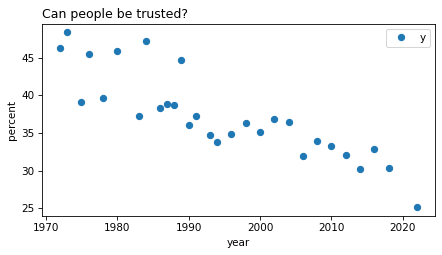

In [9]:
time_series = gss.groupby("year")["y"].mean() * 100
time_series.plot(style="o")
decorate(ylabel="percent", title="Can people be trusted?")

Sadly, levels of trust have been declining in the US for decades.

## Who is most trusting?

Who do you think is most trusting, Democrats or Republicans?
To find out, we'll use responses to another [GSS variable](https://gssdataexplorer.norc.org/variables/141/vshow), which contains responses to this question:

> Generally speaking, do you usually think of yourself as a Republican, Democrat, Independent, or what?

With these options:

```
0	Strong democrat
1	Not very strong democrat	
2	Independent, close to democrat	
3	Independent (neither, no response)	
4	Independent, close to republican	
5	Not very strong republican	
6	Strong republican
7	Other party
```

To simplify the analysis, we'll consider just three groups, Democrats (strong or not), Independent (leaning either way) and Republican (strong or not).

In [10]:
party_map = {
    0: 0,
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 2,
    6: 2,
    7: np.nan,
}

gss["partyid3"] = gss["partyid"].replace(party_map)
value_counts(gss["partyid3"])

,counts
values,
0.0,25439
1.0,26705
2.0,18338
NaN,1908


Well use this dictionary to map from codes to names.

In [11]:
party_names = {
    0: "Democrat",
    1: "Independent",
    2: "Republican",
}

The following table shows how the percentages in each group have changed over time.

In [12]:
table = (
    gss.pivot_table(index="year", columns="partyid3", values="y", aggfunc="mean") * 100
).rename(columns=party_names)

table.iloc[:10]

partyid3,Democrat,Independent,Republican
year,,,
1972,41.055341,48.325359,59.146341
1973,43.001686,49.295775,59.292035
1975,33.571429,40.525328,44.623656
1976,41.401274,44.383057,55.974843
1978,34.542587,44.649446,41.087613
1980,44.144144,44.878957,49.722222
1983,30.000000,41.403509,45.679012
1984,42.407407,48.098859,52.162162
1986,32.342657,37.894737,47.783251


Here's what the columns look like as time series.

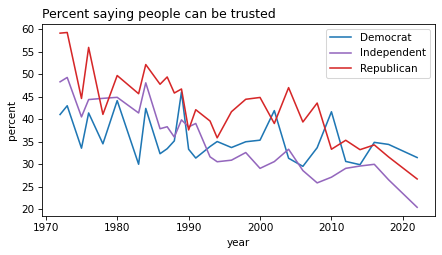

In [13]:
colors = ["C0", "C4", "C3"]
table.plot(color=colors)
decorate(ylabel="percent", title="Percent saying people can be trusted")

## Logistic Regression

Now let's build a logistic regression model in PyMC.
The fundamental idea of logistic regression is that each observation unit -- like a survey respondent -- has some latent propensity to choose one of two options, and we assume:

* The latent propensities, `z[i]`, are a linear function of explanatory variables.

* The probability a respondent chooses a particular option is `expit(z[i])`.

Where `expit` is the function that maps from log-odds to probability (defined in scipy.special).

As a first example, we'll make a model with `year` as an explanatory variable, so we'll assume

```
z = alpha + beta * year
```

In a minute we'll see how to represent this model in PyMC, but first let's prepare the data.
We'll select the rows with valid data for the response variable and `year`.

In [14]:
data = gss.dropna(subset=["y", "year"])
data.shape

(42639, 62)

And we'll extract the values as NumPy arrays.

In [15]:
y = data["y"].to_numpy()
year = data["year"].to_numpy()

We'll shift `year` so it's centered at its mean.

In [16]:
year_shift = data["year"].mean()
year = year - year_shift

Here's the complete model.

In [17]:
with pm.Model() as logistic_model:

    # Priors for intercept and slope
    alpha = pm.Normal("alpha", 0, 1)
    beta = pm.Normal("beta", 0, 1)

    # Linear predictor (log-odds)
    z = pm.Deterministic("z", alpha + beta * year)

    # The inverse logit function is called sigma
    p = pm.math.sigmoid(z)

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

Or we can skip a step by passing the logits directory to `pm.Bernoulli`.

In [18]:
with pm.Model() as logistic_model:

    # Priors for intercept and slope
    alpha = pm.Normal("alpha", 0, 1)
    beta = pm.Normal("beta", 0, 1)

    # Linear predictor (log-odds)
    z = pm.Deterministic("z", alpha + beta * year)

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", logit_p=z, observed=y)

Here's a graphical representation of the model.

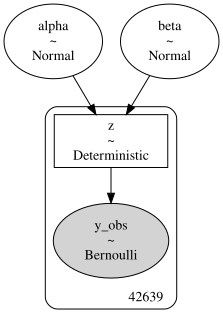

In [19]:
pm.model_to_graphviz(logistic_model)

## The posterior distribution

In [20]:
with logistic_model:
    idata = pm.sample(500)

Output()

In [21]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

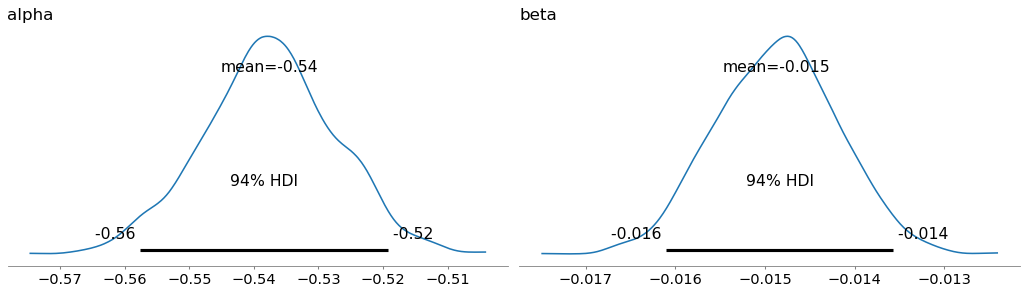

In [22]:
import arviz as az

az.plot_posterior(idata, var_names=["alpha", "beta"])
decorate()

### Comparing Prior with Posterior


In [23]:
# Sample from Prior
with logistic_model:
    idata_prior = pm.sample_prior_predictive(draws=1000, var_names=["alpha", "beta"])

idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [24]:
# Add Prior to InferenceData we already have
idata.extend(idata_prior)

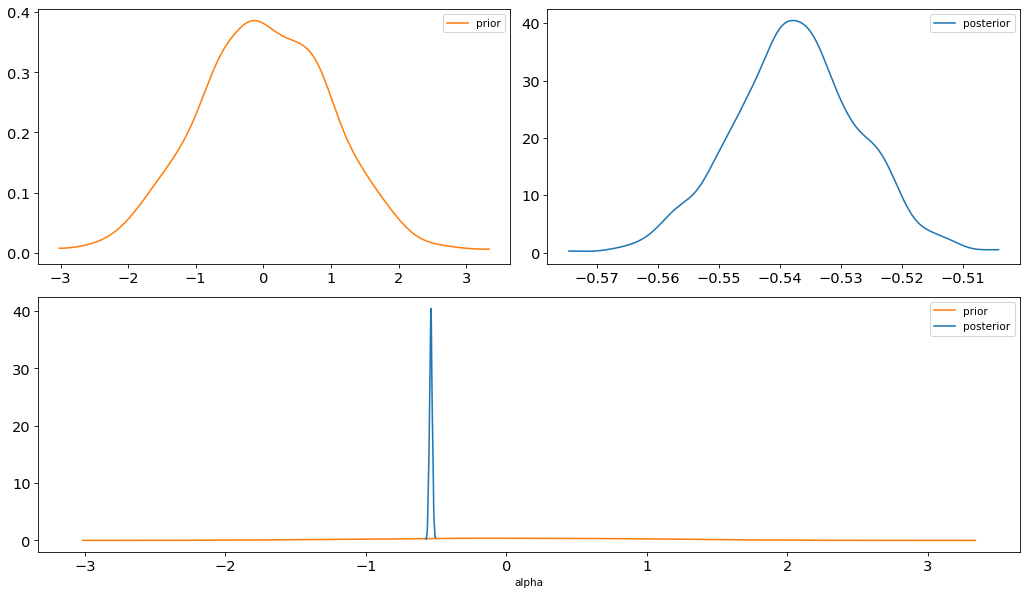

In [25]:
az.plot_dist_comparison(idata, var_names=["alpha"])
decorate()

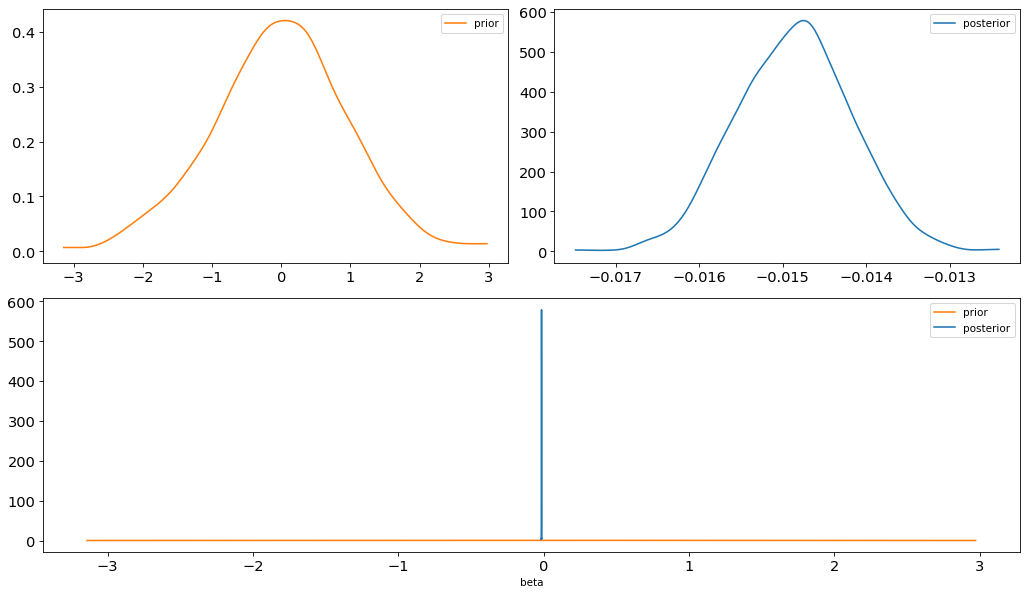

In [26]:
az.plot_dist_comparison(idata, var_names=["beta"])
decorate()

Looking at the posterior distributions of `alpha` and `beta`, we can see that they fall comfortably within the prior distributions of these parameters, which means that the priors didn't have much effect on the results.

As an experiment, try increasing or decreasing `sigma_prior` and see what effect it has on the posterior distributions.

## Sampling diagnostics

After sampling, we want to check that the process worked well — meaning:

* All chains have effectively explored the posterior distribution, and

* Successive draws within each chain are only weakly correlated (each draw should provide mostly new information).

We can check these properties visually using plot_trace, which shows:

*    On the left, the distribution from each chain should look similar — this is evidence that the chains all converged to the same region of the posterior.

*    On the right, the sequence of draws within each chain should look like uncorrelated noise (sometimes called "hairy caterpillars"). It shouldn't look like a random walk and there shouldn't be flat spots, which would suggest the chain got stuck.

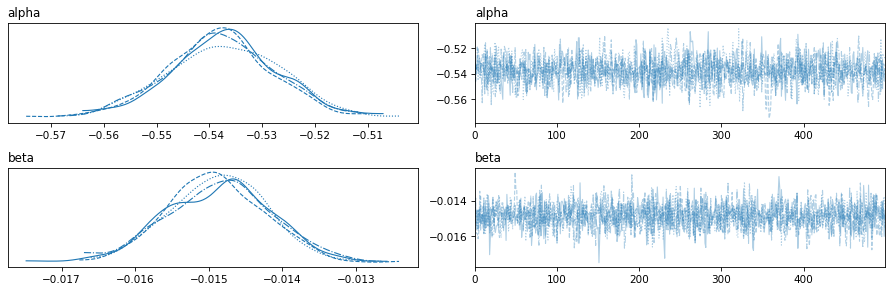

In [27]:
az.plot_trace(idata, var_names=["alpha", "beta"])
decorate()

To check these properties numerically, we can look at two key summary statistics: ESS and r-hat.

*    Effective Sample Size (ESS) tells us how much independent information the chains actually contribute. If successive values within a chain are highly correlated, the chain isn’t exploring the posterior efficiently, and ESS will be smaller than the total number of draws.

*    r-hat quantifies the difference between chains. If all chains converged to the same posterior distribution, r-hat should be close to 1. If the chains are exploring different regions, r-hat will be larger than 1, indicating failure to coverge.

In [28]:
az.summary(idata, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-0.538,0.010,-0.558,-0.519,0.0,0.0,1910.0,1599.0,1.0
beta,-0.015,0.001,-0.016,-0.014,0.0,0.0,2155.0,1695.0,1.0


### Interpreting the results

In Bayesian statistics, we have two core object we care about when analyzing our "fits". 

1. The **posterior**, which purely in mathematical terms is the left-hand-side of Bayes' Rule $p(\theta | D_{obs}) \propto \frac{ p(D_{obs} | \theta) p(\theta)}{p(D_{obs})}$. In words, the distribution over parmaters after observing the Data. 

**NOTE 1.1**:

The *posterior* is accessible to us not in terms of an equation, but in terms of samples from the distribution of interest. This is the "magic" of MCMC, and in our case canonical result of a call to `pm.sample()`.

**NOTE 1.2**:

The *posterior* lives in *parameter space*.

2. The **posterior predictive**, which is a collection of forward samples from our *observation distribution* based on the parameter sample collected in our posterior. In math, it represents access to samples from the distribution $p(D_{new} | \theta) p(\theta | D_{obs})$. The *posterior predictive*, is important for us to check what kind of *DATA* we would *predict*, once we have learned to incoporporate the information of our *observed data* in our parameter distributions.

**NOTE 2.1**:

The *posterior predictive* lives in *data space*.

Below we show how to get samples from the posterior predictive in a manual way, by extracting our posterior samples, and constructing our regression model in `numpy`. Later we will show how to use `PyMC` directly for producing samples from the posterior predictive.

#### Getting samples from the posterior predictive

In [29]:
# Collect posterior draws of alpha and beta
samples = az.extract(idata, var_names=["alpha", "beta"], num_samples=100)

alphas = samples["alpha"].to_numpy()
betas = samples["beta"].to_numpy()
betas.shape

(100,)

In [30]:
# Range of years to predict
year_range = np.arange(1970, 2031)
year_centered = year_range - year_shift

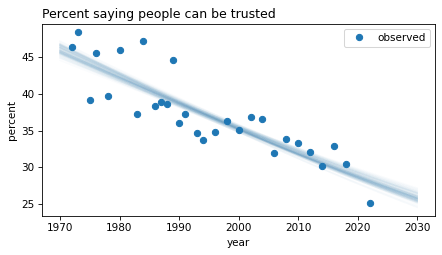

In [31]:
from scipy.special import expit

for alpha, beta in zip(alphas, betas):
    zs = alpha + beta * year_centered
    probs = expit(zs) * 100
    plt.plot(year_range, probs, color="C0", alpha=0.02)

time_series.plot(style="o", label="observed")
decorate(ylabel="percent", title="Percent saying people can be trusted")

### Centering

Because we centered `years`, the sampled slopes and intercepts are uncorrelated.

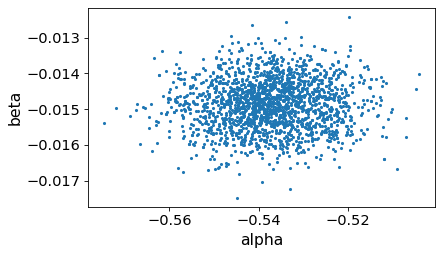

In [32]:
pm.plot_pair(idata, var_names=["alpha", "beta"])
decorate()

As an experiment, try:

* Set `year_shift=1970` and run the model again. You might get some warnings from the sampler, and `plot_pair` will show that the alphas and betas are correlated. The not-quite-centered predictor stretches the shape of the joint posterior distribution and makes it harder to sample efficiently.

* Set `year_shift=0` and run the model again. With the predictor completely uncentered, the joint posterior distribution is so stretched that the sampler diverges frequently -- and basically fails.

Without centering, the intercept represents the log-odds of the outcome when `year=0`, which is way outside the range of the data.
This forces the intercept and slope to compensate for each other — if the slope increases, the intercept must decrease to hit the same observed points.

As a general rule, it's a good idea to center continuous predictors in Bayesian regression models.

## Categorical predictors

Now let's add political party as an explanatory variable.

In [33]:
value_counts(gss["partyid3"])

,counts
values,
0.0,25439
1.0,26705
2.0,18338
NaN,1908


To prepare the data, we'll select observations where all the variables in the model are valid.

In [34]:
data = gss.dropna(subset=["y", "year", "partyid3"])
data.shape

(41605, 62)

And again we'll center the years and convert all data to NumPy arrays.

In [35]:
y = data["y"].to_numpy()

year = data["year"].to_numpy()
year_shift = data["year"].mean()
year = year - year_shift

partyid3 = data["partyid3"].astype(int).to_numpy()

This version of the model demonstrates some additional features:

* coords

* Data

* Deterministic

Other than that, it's 

In [36]:
with pm.Model(
    coords={"party_affiliation": ["Democrat", "Independent", "Republican"]}
) as logistic_model2:
    y_pt = pm.Data("y", y)
    year_pt = pm.Data("year", year)
    party_idx_pt = pm.Data("party_idx", partyid3)

    # Party-specific intercepts (one for each party)
    sigma_prior = 1
    mu_prior = 0
    alpha = pm.Normal("alpha", mu_prior, sigma_prior, dims="party_affiliation")

    # Shared slope for year (assuming effect of year is the same across parties)
    beta = pm.Normal("beta", mu_prior, sigma_prior)

    # Linear predictor (log-odds)
    z = pm.Deterministic("z", alpha[party_idx_pt] + beta * year_pt)

    # Add other quantities of interest
    p = pm.Deterministic("probabilities", pm.math.sigmoid(z))

    # Bernoulli likelihood with logit link
    y_obs = pm.Bernoulli("y_obs", p=p, observed=y_pt)

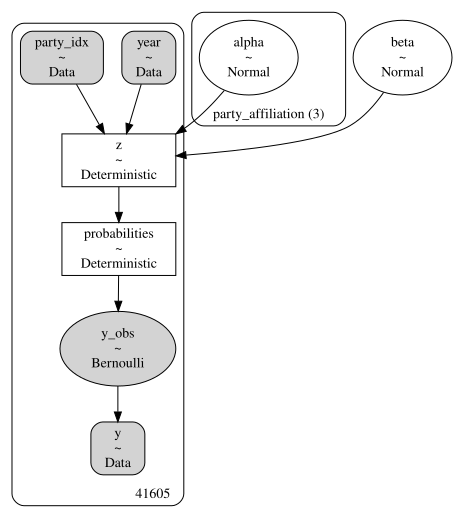

In [37]:
pm.model_to_graphviz(logistic_model2)

In [38]:
with logistic_model2:
    idata2 = pm.sample(draws=500, tune=500)

Output()

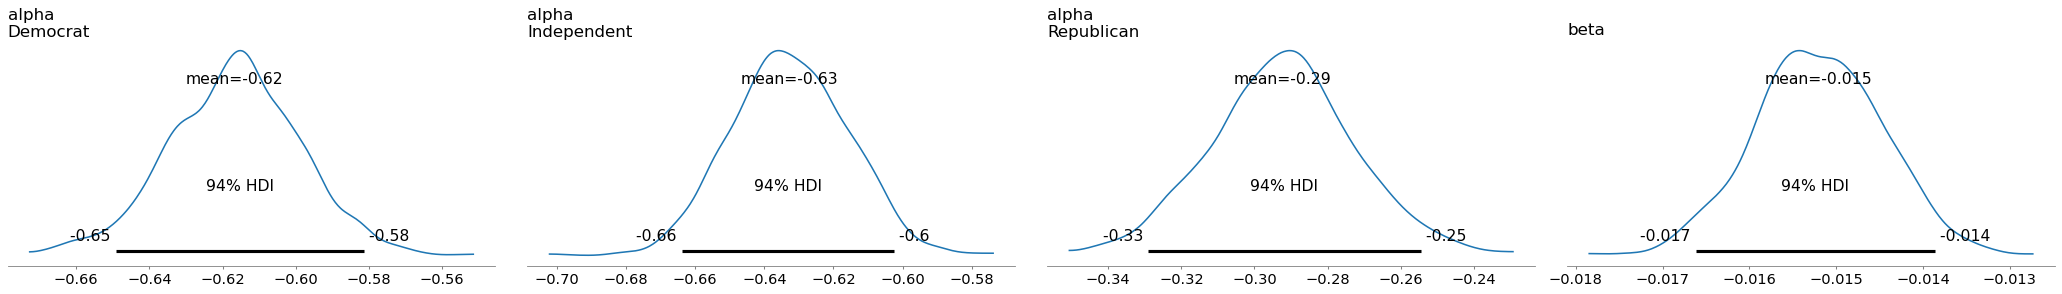

In [39]:
az.plot_posterior(idata2, var_names=["alpha", "beta"])
decorate()

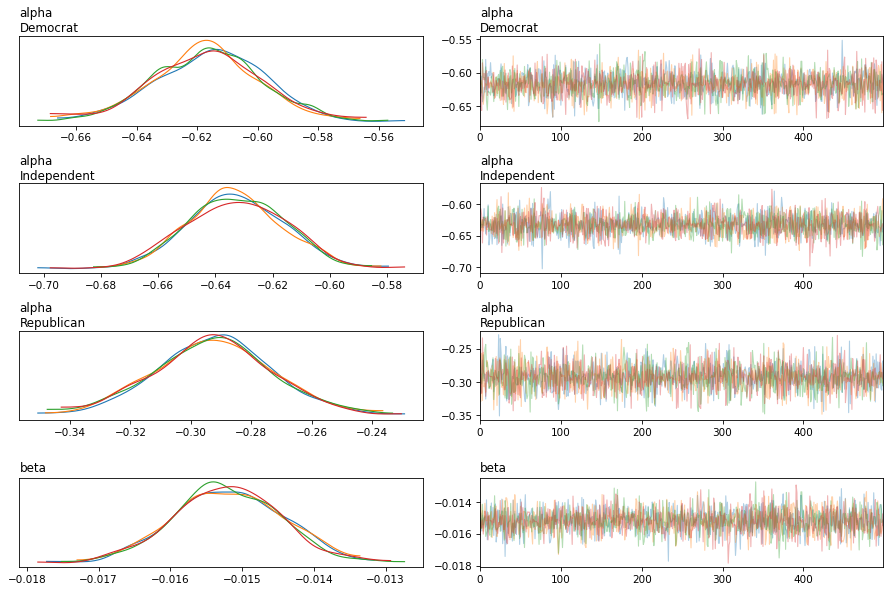

In [40]:
az.plot_trace(idata2, compact=False, var_names=["alpha", "beta"])
decorate()

In [41]:
pm.summary(idata2, var_names=["alpha", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[Democrat],-0.617,0.018,-0.649,-0.581,0.0,0.0,3319.0,1679.0,1.00
alpha[Independent],-0.633,0.017,-0.664,-0.602,0.0,0.0,3194.0,1408.0,1.00
alpha[Republican],-0.292,0.020,-0.329,-0.255,0.0,0.0,3480.0,1688.0,1.00
beta,-0.015,0.001,-0.017,-0.014,0.0,0.0,2851.0,1721.0,1.01


In [42]:
# Range of years to predict
probabilities = {}

with logistic_model2:
    for key_, party_name_ in party_names.items():
        # Assign covariates for which we want to compute the posterior predictive
        pm.set_data(
            {
                "party_idx": np.tile(key_, len(year_centered)),
                "year": year_centered,
            }
        )

        # Compute the posterior predictive
        idata = pm.compute_deterministics(idata2.posterior, var_names=["probabilities"])

        probabilities[party_name_] = az.extract(idata, num_samples=100)["probabilities"]

Output()

Output()

Output()

### Plotting the results

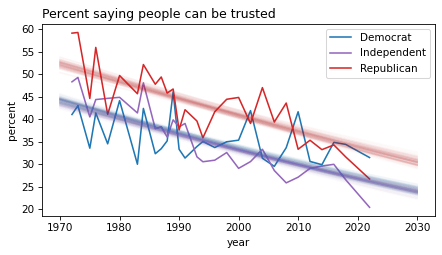

In [44]:
# Base plot per party affiliation
table.plot(color=colors)

# Plot posterior draws for each party affiliation
for key, party_name in party_names.items():
    probabilities_tmp = probabilities[party_name].to_numpy() * 100

    plt.plot(
        year_range,
        probabilities_tmp,
        color=colors[key],
        alpha=0.02,
    )

decorate(ylabel="percent", title="Percent saying people can be trusted")

### End